# Fraud Detection project 

This project presents a comprehensive machine learning solution for detecting fraudulent activities in banking and electronic payment transactions. By analyzing transaction patterns and identifying suspicious behavior, the model aims to enhance financial security, minimize fraud risks, and support more reliable and secure digital payment systems in real-world applications.

## 1- Data Reading & exploring 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"F:\Ai Course - Aibdaya\Machine learning projects\Fraud Detection\DATA\fraudTrain.csv")

In [8]:
df.shape

(1296675, 23)

In [9]:
df.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [10]:
pd.DataFrame(df.columns)

,0
0,Unnamed: 0
1,trans_date_trans_time
2,cc_num
3,merchant
4,category
5,amt
6,first
7,last
8,gender
9,street


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [12]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## 2- Data Cleaning

In [13]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [14]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## 3- Outliers

In [16]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amt'] < lower_bound) | (df['amt'] > upper_bound)]
print(f"outliers: {len(outliers)}")

outliers: 67290


In [17]:
print(outliers["amt"].max())
print(outliers["amt"].min())

28948.9
193.38


In [18]:
Q1 = df['city_pop'].quantile(0.25)
Q3 = df['city_pop'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['city_pop'] < lower_bound) | (df['city_pop'] > upper_bound)]
print(f"outliers: {len(outliers)}")

outliers: 242674


In [19]:
print(outliers["city_pop"].max())
print(outliers["city_pop"].min())

2906700
50489


We did not delete the outlier values ​​because they are indeed real and correct values, and deleting them would cause us to lose a very large amount of data.

## 4- Features Extraction

In [20]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

In [21]:
df["trans_hour"] = df["trans_date_trans_time"].dt.hour
df["trans_weekday"] = df["trans_date_trans_time"].dt.day
df["trans_day_name"] = df["trans_date_trans_time"].dt.day_name()
df["trans_month"] = df["trans_date_trans_time"].dt.month
df["trans_month_name"] = df["trans_date_trans_time"].dt.month_name()
df["trans_year"] = df["trans_date_trans_time"].dt.year

In [22]:
df["dob"] = pd.to_datetime(df["dob"])

In [23]:
df["customer_age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

In [24]:
def city_pop_bucket(i):
    if i <= 5000:
        return "Small"
    elif i > 5000 and i <= 300000:
        return "Medium"
    elif i > 300000:
        return "Large"
    
df["city_pop_bucket"] = df["city_pop"].apply(lambda x : city_pop_bucket(x))

In [25]:
df["city_pop_bucket"].value_counts()

city_pop_bucket
Small     789219
Medium    415458
Large      91998
Name: count, dtype: int64

In [26]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371 * c

df['distance_customer_merchant'] = haversine_vectorized(
    df['lat'], 
    df['long'], 
    df['merch_lat'], 
    df['merch_long']
)

In [27]:
df["distance_customer_merchant"].sort_values(ascending=False)

926894    152.117173
216446    150.834381
161915    149.804444
252294    149.431207
983865    148.852546
             ...    
513575      0.137004
42055       0.113168
273923      0.093922
556401      0.066829
381941      0.022255
Name: distance_customer_merchant, Length: 1296675, dtype: float64

In [28]:
df = df.sort_values(by='trans_date_trans_time').reset_index(drop=True)

In [29]:
df['customer_avg_amt_so_far'] = (
    df.groupby('cc_num')['amt']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

In [30]:
df['max_distance_last_txn'] = (
    df.groupby('cc_num')['distance_customer_merchant']
    .shift(1)
)

df['max_distance_last_txn'] = df['max_distance_last_txn'].fillna(0)

In [31]:
df['amt_deviation_from_avg'] = df['amt'] / (df['customer_avg_amt_so_far'] + 0.001)

In [32]:
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

df = df.set_index('trans_date_trans_time')

df['customer_txn_count_1h'] = (
    df.groupby('cc_num')['amt']
      .rolling('1h', closed='left')
      .count()
      .reset_index(level=0, drop=True)
      .to_numpy()         
)

df = df.reset_index()

df['customer_txn_count_1h'] = df['customer_txn_count_1h'].fillna(0).astype(int)

In [33]:
pd.DataFrame(df.columns)

,0
0,trans_date_trans_time
1,cc_num
2,merchant
3,category
4,amt
5,first
6,last
7,gender
8,street
9,city


In [34]:
df.to_csv("new_dtat_fraud_detection_analysis.csv",index=False)

## 5- Features Selection

In [35]:
df = df.sort_values(by='trans_date_trans_time')

In [36]:
cols_to_encode = [
    'merchant',
    'category',
    'gender',
    'state',
    'city_pop_bucket',
    'trans_day_name',
    'trans_month_name'
]

from sklearn.preprocessing import LabelEncoder

for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

for col in cols_to_encode:
    print(f"{col} : {df[col].unique()[:10]}")

merchant : [514 241 390 360 297 607 534 107 250 563]
category : [ 8  4  0  2  9  3 11 12  1 10]
gender : [0 1]
state : [27 47 13 26 45 38 16 42 12 49]
city_pop_bucket : [2 1 0]
trans_day_name : [5 6 4 0 2 3 1]
trans_month_name : [ 4  3  7  0  8  6  5  1 11 10]


In [37]:
X = df[[
    'amt',
    'category',
    'trans_hour',
    'trans_weekday',
    'customer_age',
    'distance_customer_merchant',
    'customer_avg_amt_so_far',
    'amt_deviation_from_avg',
    'customer_txn_count_1h',
    'max_distance_last_txn',
    'city_pop',
    'gender',
]]

y = df["is_fraud"]

In [38]:
X = X.astype(float)
y = y.astype(int)

## 6- Models

In [39]:
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel,SelectKBest,chi2

In [41]:
def Models(Model):

    Model.fit(X_train, y_train)
    print(f'Train Score is : {Model.score(X_train, y_train)}')
    print(f'Test Score is : {Model.score(X_test, y_test)}')

    y_pred = Model.predict(X_test)
    print(f'accuracy_score is  : {accuracy_score(y_test, y_pred)}')
    print(f'f1_score is  : {f1_score(y_test, y_pred, average="weighted")}')
    print(f'recall_score is  : {recall_score(y_test, y_pred, average="weighted")}')
    print(f'precision_score is  : {precision_score(y_test, y_pred, average="weighted")}')
    CM = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix is : \n', CM)
    print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

    print(list(y_test)[:10])
    print(list(y_pred)[:10])
    print('=' * 100)

In [42]:
RandomForestClassifierModel = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

LogisticRegressionModel = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

XGBClassifierModel = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [43]:
Models(XGBClassifierModel)

Train Score is : 0.9992403647791467
Test Score is : 0.9985308577708369
accuracy_score is  : 0.9985308577708369
f1_score is  : 0.9984659488801501
recall_score is  : 0.9985308577708369
precision_score is  : 0.9984831611679674
Confusion Matrix is : 
 [[257732     65]
 [   316   1222]]
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00    257797
     Class 1       0.95      0.79      0.87      1538

    accuracy                           1.00    259335
   macro avg       0.97      0.90      0.93    259335
weighted avg       1.00      1.00      1.00    259335

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [44]:
#Models(RandomForestClassifierModel)

In [45]:
#Models(LogisticRegressionModel)

## 7- Evaluation

In [46]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob = XGBClassifierModel.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))

ROC-AUC: 0.9984159243087068
PR-AUC : 0.931442410606755


## 8- Feature Importance

In [47]:
XGBClassifierModel.feature_importances_

array([0.163891  , 0.15879399, 0.14494061, 0.01043403, 0.02969084,
       0.00679297, 0.08325715, 0.26321077, 0.09331934, 0.00686829,
       0.01313079, 0.02567021], dtype=float32)

In [48]:
XGBClassifierModel.feature_names_in_

array(['amt', 'category', 'trans_hour', 'trans_weekday', 'customer_age',
       'distance_customer_merchant', 'customer_avg_amt_so_far',
       'amt_deviation_from_avg', 'customer_txn_count_1h',
       'max_distance_last_txn', 'city_pop', 'gender'], dtype='<U26')

In [49]:
y_pred = XGBClassifierModel.predict(X_test)
CM = confusion_matrix(y_test, y_pred)
CM

array([[257732,     65],
       [   316,   1222]])

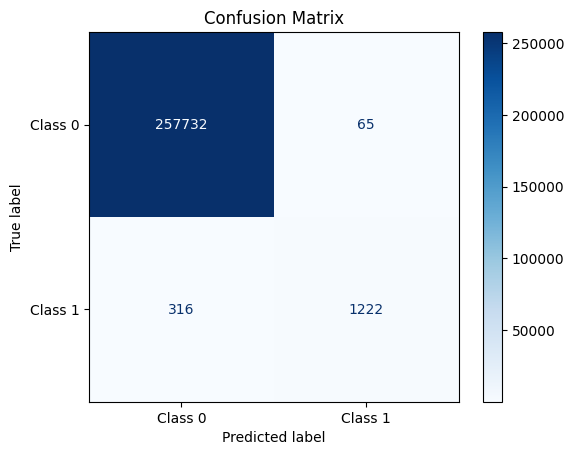

In [50]:
class_names = ['Class 0', 'Class 1']

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=class_names)


disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

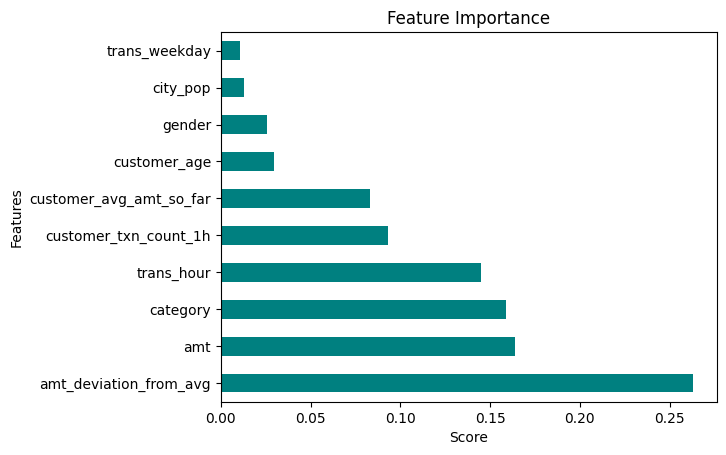

In [51]:
importances = XGBClassifierModel.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)

feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Feature Importance")
plt.xlabel("Score")
plt.ylabel("Features")
plt.show()

## 9- Model Save

In [52]:
import pickle

with open("Fraud_Detection.pkl", "wb") as file:
    pickle.dump(XGBClassifierModel, file)